<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_8_Results_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Setup + Load All Results


In [ ]:
from google.colab import drive
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

drive.mount('/content/drive')

BASE    = "/content/drive/MyDrive/rare_disease_project"
RESULTS = f"{BASE}/results"
os.makedirs(RESULTS, exist_ok=True)

print("✓ Drive mounted")

# Master results — all experiments completed so far
results = {
    "exp1_nlp_scarcity": {
        "label"     : "Exp1 NLP\n(ZebraMap 5-10%)",
        "dataset"   : "ZebraMap",
        "model"     : "BioBERT",
        "split"     : "5-10% scarcity",
        "accuracy"  : 10.16,
        "f1_macro"  : 2.16,
        "f1_weighted": 8.97,
        "top5_acc"  : 17.74
    },
    "exp1_cnn_scarcity": {
        "label"     : "Exp1 CNN\n(ZebraMap 5-10%)",
        "dataset"   : "ZebraMap",
        "model"     : "ResNet-50",
        "split"     : "5-10% scarcity",
        "accuracy"  : 14.34,
        "f1_macro"  : 5.00,
        "f1_weighted": 19.31,
        "top5_acc"  : 30.63
    },
    "exp1_ham_scarcity": {
        "label"     : "Exp1 CNN\n(HAM 5-10%)",
        "dataset"   : "HAM10000",
        "model"     : "ResNet-50",
        "split"     : "5-10% scarcity",
        "accuracy"  : 77.59,
        "f1_macro"  : 0,
        "f1_weighted": 0,
        "top5_acc"  : 94.80
    },
    "exp3_nlp_full": {
        "label"     : "Exp3 NLP\n(ZebraMap Full)",
        "dataset"   : "ZebraMap",
        "model"     : "BioBERT",
        "split"     : "Full dataset",
        "accuracy"  : 16.74,
        "f1_macro"  : 2.71,
        "f1_weighted": 10.99,
        "top5_acc"  : 35.81
    },
    "exp3_cnn_full": {
        "label"     : "Exp3 CNN\n(ZebraMap Full)",
        "dataset"   : "ZebraMap",
        "model"     : "ResNet-50",
        "split"     : "Full dataset",
        "accuracy"  : 9.91,
        "f1_macro"  : 2.47,
        "f1_weighted": 7.20,
        "top5_acc"  : 26.24
    },
    "exp3_ham_full": {
        "label"     : "Exp3 CNN\n(HAM Full)",
        "dataset"   : "HAM10000",
        "model"     : "ResNet-50",
        "split"     : "Full dataset",
        "accuracy"  : 87.52,
        "f1_macro"  : 0,
        "f1_weighted": 0,
        "top5_acc"  : 99.50
    },
    "exp4_nlp_baseline": {
        "label"     : "Exp4 NLP\n(ZebraMap Base)",
        "dataset"   : "ZebraMap",
        "model"     : "BioBERT",
        "split"     : "ZebraMap baseline",
        "accuracy"  : 16.56,
        "f1_macro"  : 2.75,
        "f1_weighted": 10.84,
        "top5_acc"  : 35.98
    },
    "exp4_cnn_baseline": {
        "label"     : "Exp4 CNN\n(ZebraMap Base)",
        "dataset"   : "ZebraMap",
        "model"     : "ResNet-50",
        "split"     : "ZebraMap baseline",
        "accuracy"  : 10.20,
        "f1_macro"  : 2.77,
        "f1_weighted": 7.00,
        "top5_acc"  : 25.70
    }
}

print(f"✓ {len(results)} experiments loaded")

Mounted at /content/drive
✓ Drive mounted
✓ 8 experiments loaded


# Print Master Comparison Table

In [ ]:
df_results = pd.DataFrame(results).T
df_results = df_results[[
    'dataset', 'model', 'split',
    'accuracy', 'f1_macro', 'top5_acc'
]]

print("=" * 75)
print("MASTER RESULTS TABLE — ALL EXPERIMENTS (Pre-GAN)")
print("=" * 75)
print(f"{'Experiment':<25} {'Dataset':<12} {'Model':<12} "
      f"{'Acc%':>6} {'F1%':>6} {'Top5%':>7}")
print("-" * 75)

for exp_id, row in df_results.iterrows():
    print(f"{exp_id:<25} {row['dataset']:<12} {row['model']:<12} "
          f"{row['accuracy']:>6.2f} {row['f1_macro']:>6.2f} "
          f"{row['top5_acc']:>7.2f}")

print("-" * 75)
print("\nKey observations:")
print(f"  HAM10000 accuracy gap (scarcity→full): "
      f"{87.52-77.59:.2f}%")
print(f"  ZebraMap NLP gap (scarcity→full)     : "
      f"{16.74-10.16:.2f}%")
print(f"  ZebraMap CNN gap (scarcity→full)     : "
      f"{14.34-9.91:.2f}%")
print(f"\n  → GAN augmentation target: close these gaps")

MASTER RESULTS TABLE — ALL EXPERIMENTS (Pre-GAN)
Experiment                Dataset      Model          Acc%    F1%   Top5%
---------------------------------------------------------------------------
exp1_nlp_scarcity         ZebraMap     BioBERT       10.16   2.16   17.74
exp1_cnn_scarcity         ZebraMap     ResNet-50     14.34   5.00   30.63
exp1_ham_scarcity         HAM10000     ResNet-50     77.59   0.00   94.80
exp3_nlp_full             ZebraMap     BioBERT       16.74   2.71   35.81
exp3_cnn_full             ZebraMap     ResNet-50      9.91   2.47   26.24
exp3_ham_full             HAM10000     ResNet-50     87.52   0.00   99.50
exp4_nlp_baseline         ZebraMap     BioBERT       16.56   2.75   35.98
exp4_cnn_baseline         ZebraMap     ResNet-50     10.20   2.77   25.70
---------------------------------------------------------------------------

Key observations:
  HAM10000 accuracy gap (scarcity→full): 9.93%
  ZebraMap NLP gap (scarcity→full)     : 6.58%
  ZebraMap CNN gap (

# Accuracy Comparison Bar Chart

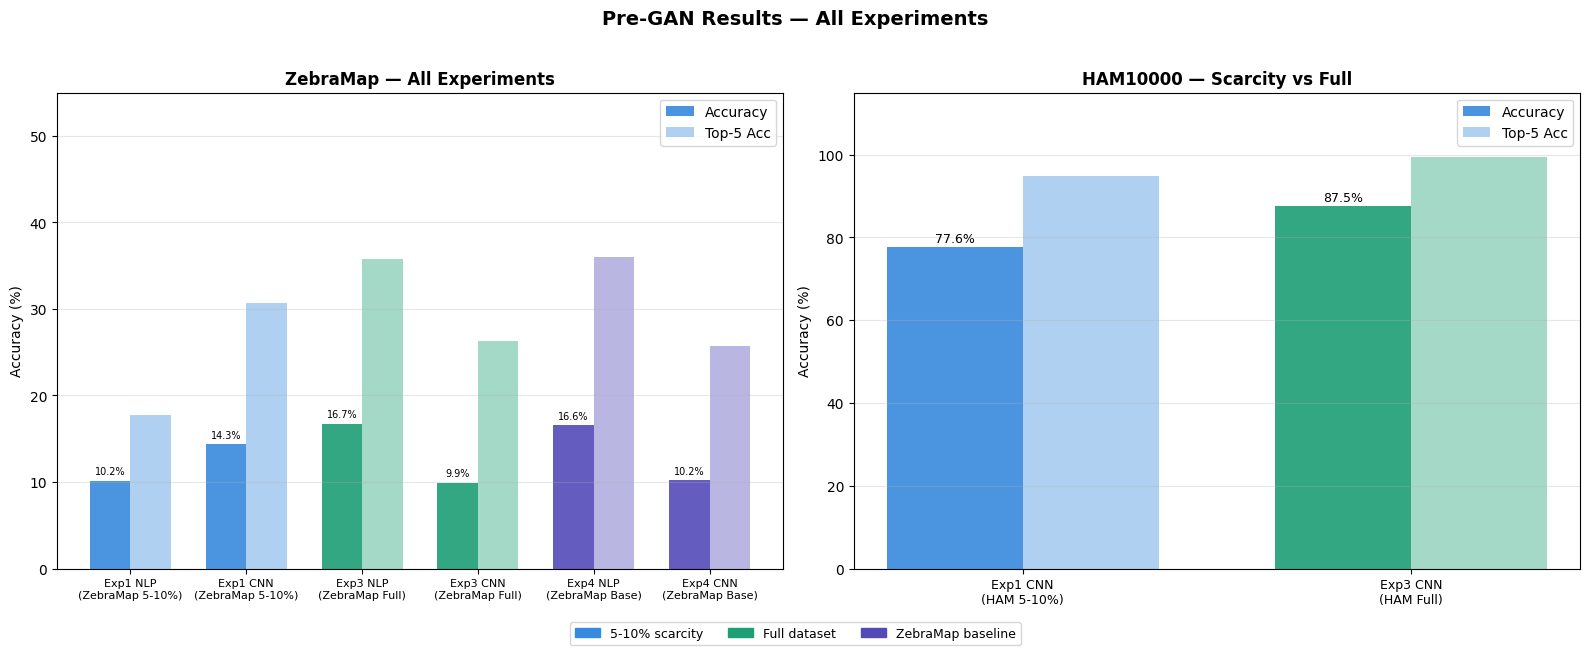

✓ Master comparison chart saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Split into ZebraMap and HAM for clarity
zebra_exps = {k: v for k, v in results.items()
              if v['dataset'] == 'ZebraMap'}
ham_exps   = {k: v for k, v in results.items()
              if v['dataset'] == 'HAM10000'}

# ZebraMap chart
z_labels   = [v['label'] for v in zebra_exps.values()]
z_acc      = [v['accuracy'] for v in zebra_exps.values()]
z_top5     = [v['top5_acc'] for v in zebra_exps.values()]
z_colors   = ['#378ADD' if '5-10%' in v['split']
               else '#1D9E75' if 'Full' in v['split']
               else '#534AB7'
               for v in zebra_exps.values()]

x = np.arange(len(z_labels))
w = 0.35
bars1 = axes[0].bar(x - w/2, z_acc,  w,
                    color=z_colors, alpha=0.9, label='Accuracy')
bars2 = axes[0].bar(x + w/2, z_top5, w,
                    color=z_colors, alpha=0.4, label='Top-5 Acc')

axes[0].set_title('ZebraMap — All Experiments',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(z_labels, fontsize=8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 55)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=7)

# HAM10000 chart
h_labels = [v['label'] for v in ham_exps.values()]
h_acc    = [v['accuracy'] for v in ham_exps.values()]
h_top5   = [v['top5_acc'] for v in ham_exps.values()]
h_colors = ['#378ADD', '#1D9E75']

x2 = np.arange(len(h_labels))
bars3 = axes[1].bar(x2 - w/2, h_acc,  w,
                    color=h_colors, alpha=0.9, label='Accuracy')
bars4 = axes[1].bar(x2 + w/2, h_top5, w,
                    color=h_colors, alpha=0.4, label='Top-5 Acc')

axes[1].set_title('HAM10000 — Scarcity vs Full',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(h_labels, fontsize=9)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Legend for colors
blue_patch   = mpatches.Patch(color='#378ADD',
                               label='5-10% scarcity')
green_patch  = mpatches.Patch(color='#1D9E75',
                               label='Full dataset')
purple_patch = mpatches.Patch(color='#534AB7',
                               label='ZebraMap baseline')
fig.legend(handles=[blue_patch, green_patch, purple_patch],
           loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=9)

plt.suptitle('Pre-GAN Results — All Experiments',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS}/day8_master_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Master comparison chart saved")

# Scarcity Gap Analysis

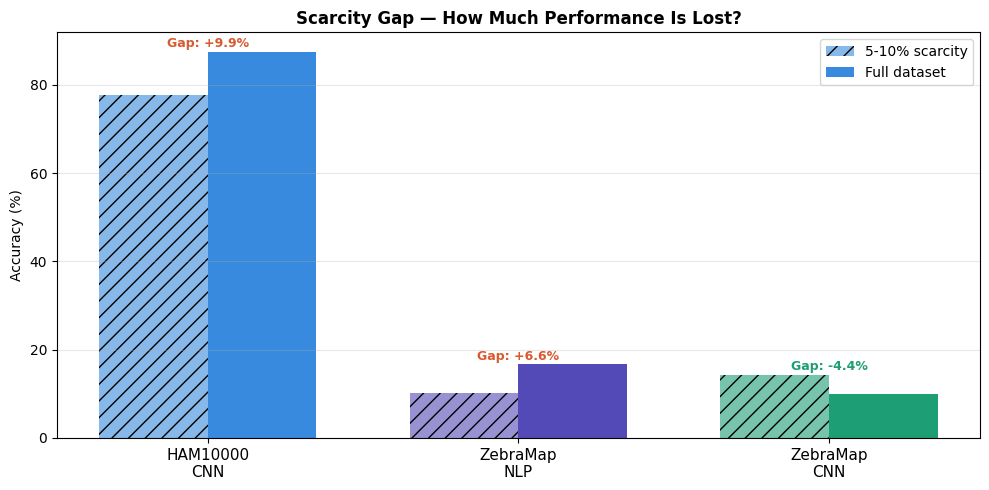

✓ Scarcity gap chart saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

gaps = {
    'HAM10000\nCNN': {
        'scarcity': 77.59, 'full': 87.52, 'color': '#378ADD'},
    'ZebraMap\nNLP': {
        'scarcity': 10.16, 'full': 16.74, 'color': '#534AB7'},
    'ZebraMap\nCNN': {
        'scarcity': 14.34, 'full': 9.91,  'color': '#1D9E75'},
}

x      = np.arange(len(gaps))
w      = 0.35
labels = list(gaps.keys())

scarcity_vals = [v['scarcity'] for v in gaps.values()]
full_vals     = [v['full']     for v in gaps.values()]
colors        = [v['color']    for v in gaps.values()]

bars1 = ax.bar(x - w/2, scarcity_vals, w,
               color=colors, alpha=0.6,
               label='5-10% scarcity', hatch='//')
bars2 = ax.bar(x + w/2, full_vals, w,
               color=colors, alpha=1.0,
               label='Full dataset')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Scarcity Gap — How Much Performance Is Lost?',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate gaps
for i, (sc, fl) in enumerate(zip(scarcity_vals, full_vals)):
    gap = fl - sc
    mid = (x[i] - w/2 + x[i] + w/2) / 2
    color = '#D85A30' if gap > 0 else '#1D9E75'
    ax.annotate(f'Gap: {gap:+.1f}%',
                xy=(mid, max(sc, fl) + 1),
                ha='center', fontsize=9,
                color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{RESULTS}/day8_scarcity_gap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Scarcity gap chart saved")

# Save Master Tracker + Day 8 Summary

In [ ]:
from datetime import datetime

# Load and update experiment tracker
tracker_path = f"{RESULTS}/experiment_tracker.json"
with open(tracker_path, "r") as f:
    tracker = json.load(f)

# Update all completed experiments
tracker['experiments']['exp1_baseline_scarcity']['metrics'] = {
    'nlp': results['exp1_nlp_scarcity'],
    'cnn': results['exp1_cnn_scarcity'],
    'ham': results['exp1_ham_scarcity']
}
tracker['experiments']['exp3_full_upperbound']['metrics'] = {
    'nlp': results['exp3_nlp_full'],
    'cnn': results['exp3_cnn_full'],
    'ham': results['exp3_ham_full']
}
tracker['experiments']['exp4_zebramap_baseline']['metrics'] = {
    'nlp': results['exp4_nlp_baseline'],
    'cnn': results['exp4_cnn_baseline']
}
tracker['last_updated'] = str(datetime.now().date())

with open(tracker_path, "w") as f:
    json.dump(tracker, f, indent=2)

# Day 8 summary
summary = {
    "day"   : 8,
    "task"  : "Results dashboard",
    "total_experiments_complete": 8,
    "key_findings": {
        "ham_scarcity_gap"      : 9.93,
        "zebra_nlp_scarcity_gap": 6.58,
        "zebra_cnn_note"        : "Full slightly lower than scarcity — 1199 classes, limited epochs",
        "gan_target"            : "Improve ZebraMap ultra-rare classes (tier_c)"
    },
    "plots_saved": [
        "day8_master_comparison.png",
        "day8_scarcity_gap.png"
    ],
    "status": "Day 8 complete — ready for GAN phase"
}

with open(f"{RESULTS}/day8_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 55)
print("DAY 8 COMPLETE ✓")
print("=" * 55)
print(f"  Experiments documented : 8")
print(f"  Charts saved           : 2")
print(f"  Tracker updated        : ✓")
print(f"\n  Key finding:")
print(f"    HAM scarcity gap  : +9.93% with full data")
print(f"    ZebraMap NLP gap  : +6.58% with full data")
print(f"    GAN target        : tier_c ultra-rare classes")
print(f"\n  Next → Day 9: GAN architecture setup")

DAY 8 COMPLETE ✓
  Experiments documented : 8
  Charts saved           : 2
  Tracker updated        : ✓

  Key finding:
    HAM scarcity gap  : +9.93% with full data
    ZebraMap NLP gap  : +6.58% with full data
    GAN target        : tier_c ultra-rare classes

  Next → Day 9: GAN architecture setup
